## 03 — Mapa Ideológico e Blocos Parlamentares

Posiciona cada deputado num espaço 2D (PCA) com base em como votaram no Plenário em 2025.  
Depois agrupa os deputados em blocos ideológicos com K-Means.

**Etapas:**
1. Codificação dos votos (Sim → +1, Não → −1, Abstenção/Obstrução → 0, Artigo 17 → NaN)
2. Construção da matriz deputado × votação
3. PCA para reduzir a ~430 dimensões para 2
4. K-Means para identificar blocos ideológicos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

PROCESSED_DIR = '../data/processed/'

df_deputados = pd.read_parquet(f'{PROCESSED_DIR}deputados.parquet')
df_votos = pd.read_parquet(f'{PROCESSED_DIR}votos.parquet')
df_votacoes = pd.read_parquet(f'{PROCESSED_DIR}votacoes.parquet')

## 1. Codificação dos votos

Mapeamos cada tipo de voto para um valor numérico:
- **Sim** → +1 (a favor)
- **Não** → −1 (contra)
- **Abstenção / Obstrução** → 0 (posição neutra/procedimental)
- **Artigo 17** → NaN (impedido de votar — não é uma escolha política)

In [2]:
ENCODING = {
    'Sim': 1,
    'Não': -1,
    'Abstenção': 0,
    'Obstrução': 0,
    'Artigo 17': np.nan,
}

df_votos['voto_encoded'] = df_votos['voto'].map(ENCODING)

print("Distribuição dos valores codificados:")
print(df_votos['voto_encoded'].value_counts(dropna=False))

Distribuição dos valores codificados:
voto_encoded
 1.0    99870
-1.0    69794
 NaN      841
 0.0      712
Name: count, dtype: int64


## 2. Matriz deputado × votação

Pivotamos os votos para uma matriz onde cada linha é um deputado e cada coluna é uma votação.  
Filtramos deputados com menos de 50 votos (suplentes com pouca participação).  
NaN restantes (ausência) são preenchidos com 0 (posição neutra).

In [3]:
MIN_VOTES = 50

matrix = df_votos.pivot_table(
    index='deputado_id',
    columns='votacao_id',
    values='voto_encoded',
    aggfunc='first',
)

non_nan_counts = matrix.notna().sum(axis=1)
matrix = matrix.loc[non_nan_counts >= MIN_VOTES]

matrix = matrix.fillna(0)

print(f"Matriz: {matrix.shape[0]} deputados × {matrix.shape[1]} votações")
print(f"Deputados removidos (< {MIN_VOTES} votos): {non_nan_counts.shape[0] - matrix.shape[0]}")

Matriz: 532 deputados × 428 votações
Deputados removidos (< 50 votos): 19


## 3. PCA — Redução de dimensionalidade

Centralizamos a matriz (subtraímos a média de cada coluna) para remover o viés de que a maioria dos votos é "Sim".  
Sem centralizar, o PC1 capturaria apenas "quem vota mais" em vez de ideologia.

Aplicamos PCA para projetar os ~430 eixos de votação em apenas 2 componentes principais.

In [4]:
matrix_centered = matrix - matrix.mean(axis=0)

pca = PCA(n_components=2)
coords = pca.fit_transform(matrix_centered)

df_pca = pd.DataFrame({
    'deputado_id': matrix.index,
    'PC1': coords[:, 0],
    'PC2': coords[:, 1],
})

df_pca = df_pca.merge(df_deputados[['deputado_id', 'nome', 'deputado_siglaPartido', 'deputado_siglaUf']],
                       on='deputado_id', how='left')

print(f"Variância explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total (2 componentes): {pca.explained_variance_ratio_.sum():.1%}")

Variância explicada: PC1=40.3%, PC2=9.6%
Total (2 componentes): 50.0%


## 4. Mapa ideológico — PCA colorido por partido

Cada ponto é um deputado. A posição reflete como votaram em relação aos demais.  
Deputados próximos no gráfico tendem a votar de forma parecida.

Colorimos por partido para verificar se o PCA captura a estrutura ideológica esperada (ex: PT e PL em lados opostos).

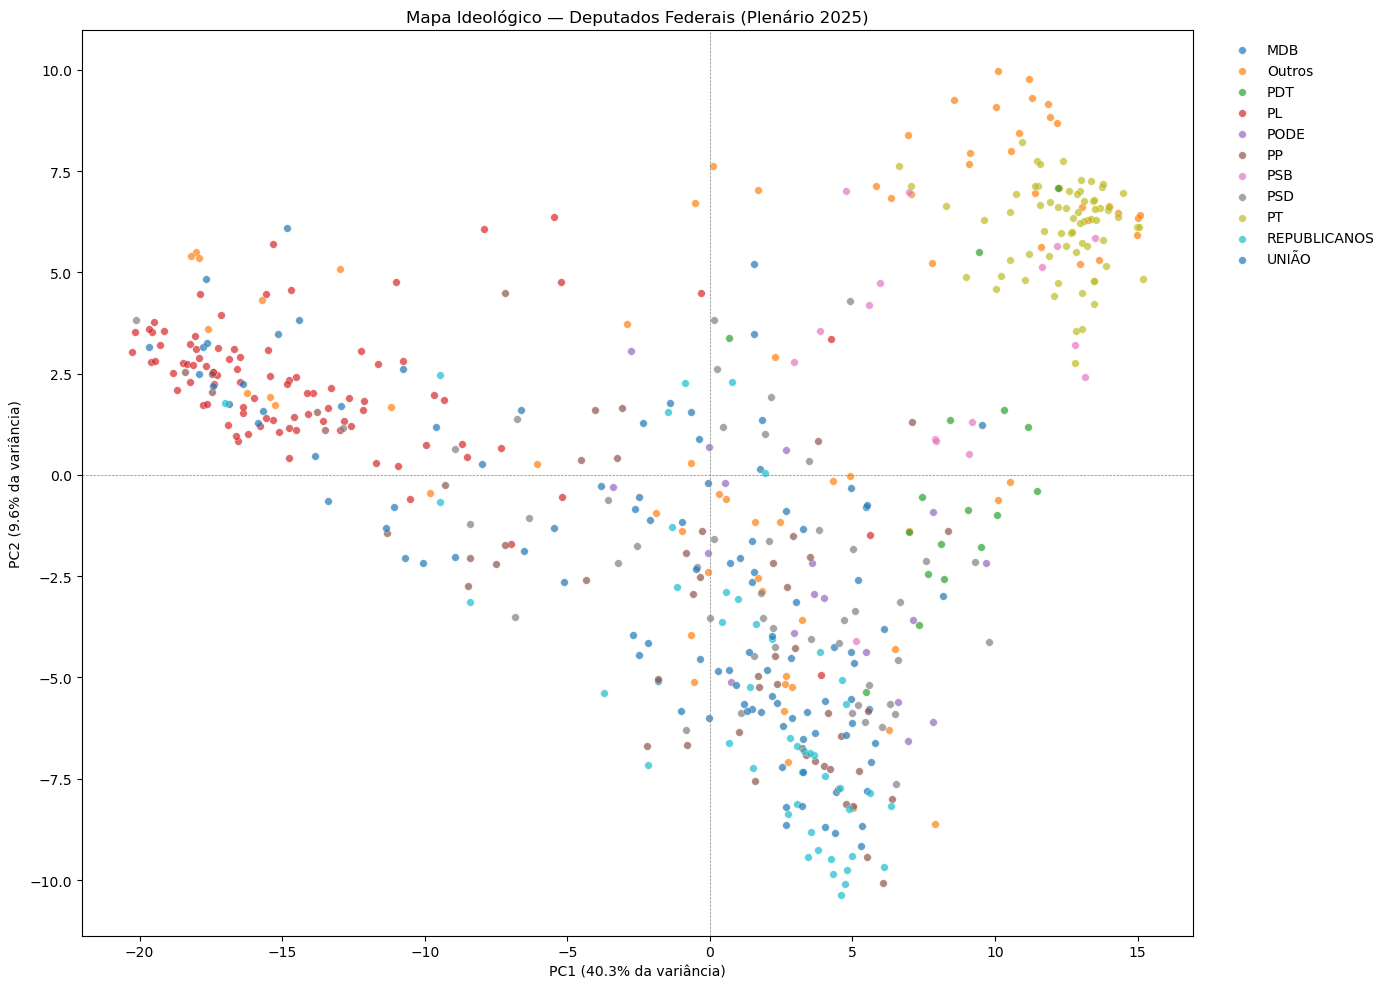

In [5]:
top_parties = df_pca['deputado_siglaPartido'].value_counts().head(10).index.tolist()
df_pca['partido_plot'] = df_pca['deputado_siglaPartido'].where(
    df_pca['deputado_siglaPartido'].isin(top_parties), other='Outros'
)

fig, ax = plt.subplots(figsize=(14, 10))

parties = df_pca['partido_plot'].unique()
palette = sns.color_palette('tab10', n_colors=len(parties))
color_map = dict(zip(sorted(parties), palette))

for party in sorted(parties):
    mask = df_pca['partido_plot'] == party
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        label=party,
        color=color_map[party],
        alpha=0.7,
        s=30,
        edgecolors='white',
        linewidth=0.3,
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
ax.set_title('Mapa Ideológico — Deputados Federais (Plenário 2025)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

## 5. Verificação de sanidade

O PC1 deve separar esquerda/direita. Verificamos imprimindo a média de PC1 por partido — PT e PSOL devem estar num extremo, PL e NOVO no outro.

In [6]:
party_pc1 = (
    df_pca
    .groupby('deputado_siglaPartido')['PC1']
    .agg(['mean', 'count'])
    .sort_values('mean')
)

party_pc1[party_pc1['count'] >= 5]

,mean,count
deputado_siglaPartido,,
NOVO,-16.562030,5
PL,-14.074926,91
PRD,-5.376099,6
UNIÃO,-2.647496,60
PP,-1.075685,52
MDB,-0.769490,44
PSDB,0.645346,15
PSD,1.317251,48
REPUBLICANOS,1.428556,46


## 6. K-Means — Identificação de blocos

Agrupamos os deputados em **k=3** clusters no espaço PCA (PC1, PC2).  
A expectativa é que os clusters correspondam aproximadamente a: governo, oposição e centrão.

c:\Users\Usuario\anaconda3\envs\data-project\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


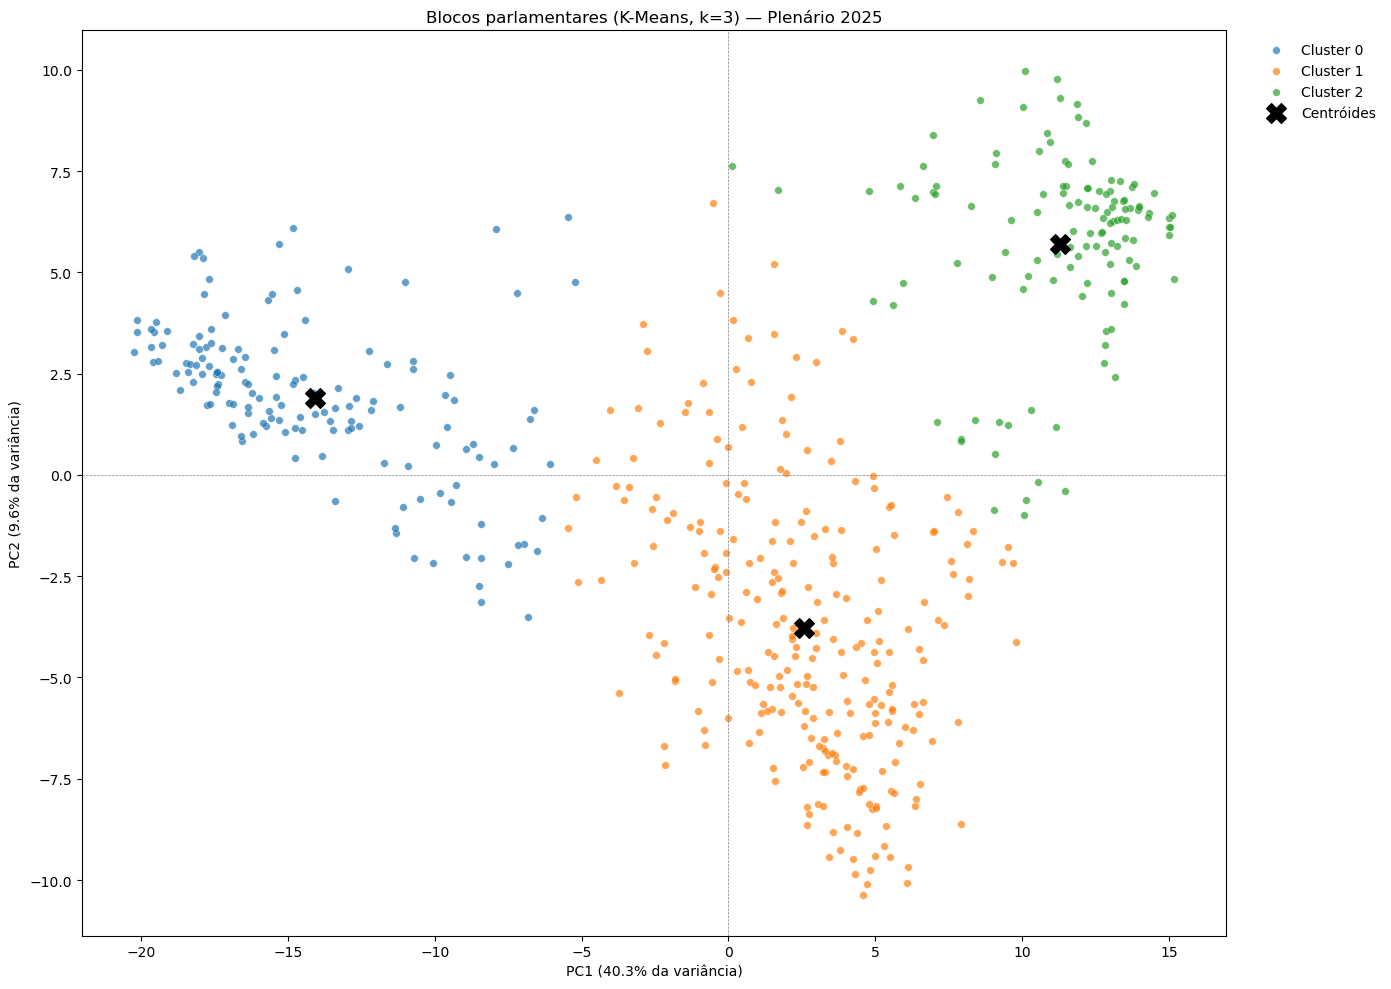

In [7]:
K = 3

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_pca['cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']])

fig, ax = plt.subplots(figsize=(14, 10))

for cluster in range(K):
    mask = df_pca['cluster'] == cluster
    ax.scatter(
        df_pca.loc[mask, 'PC1'],
        df_pca.loc[mask, 'PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7,
        s=30,
        edgecolors='white',
        linewidth=0.3,
    )

centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, zorder=5, label='Centróides')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
ax.set_title(f'Blocos parlamentares (K-Means, k={K}) — Plenário 2025')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

## 7. Composição dos clusters

Para cada cluster, mostramos o tamanho e os principais partidos.  
Isso permite verificar se os agrupamentos fazem sentido político.

In [8]:
for cluster in range(K):
    members = df_pca[df_pca['cluster'] == cluster]
    top_parties = members['deputado_siglaPartido'].value_counts().head(5)
    print(f"\n{'='*50}")
    print(f"Cluster {cluster}: {len(members)} deputados | PC1 médio: {members['PC1'].mean():.2f}")
    print(f"Principais partidos:")
    for party, count in top_parties.items():
        print(f"  {party}: {count}")


Cluster 0: 147 deputados | PC1 médio: -14.08
Principais partidos:
  PL: 86
  UNIÃO: 20
  PP: 12
  PSD: 7
  MDB: 6

Cluster 1: 261 deputados | PC1 médio: 2.57
Principais partidos:
  REPUBLICANOS: 42
  PSD: 40
  UNIÃO: 39
  PP: 39
  MDB: 38

Cluster 2: 124 deputados | PC1 médio: 11.28
Principais partidos:
  PT: 67
  PSOL: 14
  PSB: 13
  PCdoB: 9
  PDT: 8


## 8. Experimentando com k=4 e k=5

Testamos outros valores de k para ver se emerge uma estrutura mais fina (ex: separar centrão em sub-blocos).

c:\Users\Usuario\anaconda3\envs\data-project\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Usuario\anaconda3\envs\data-project\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


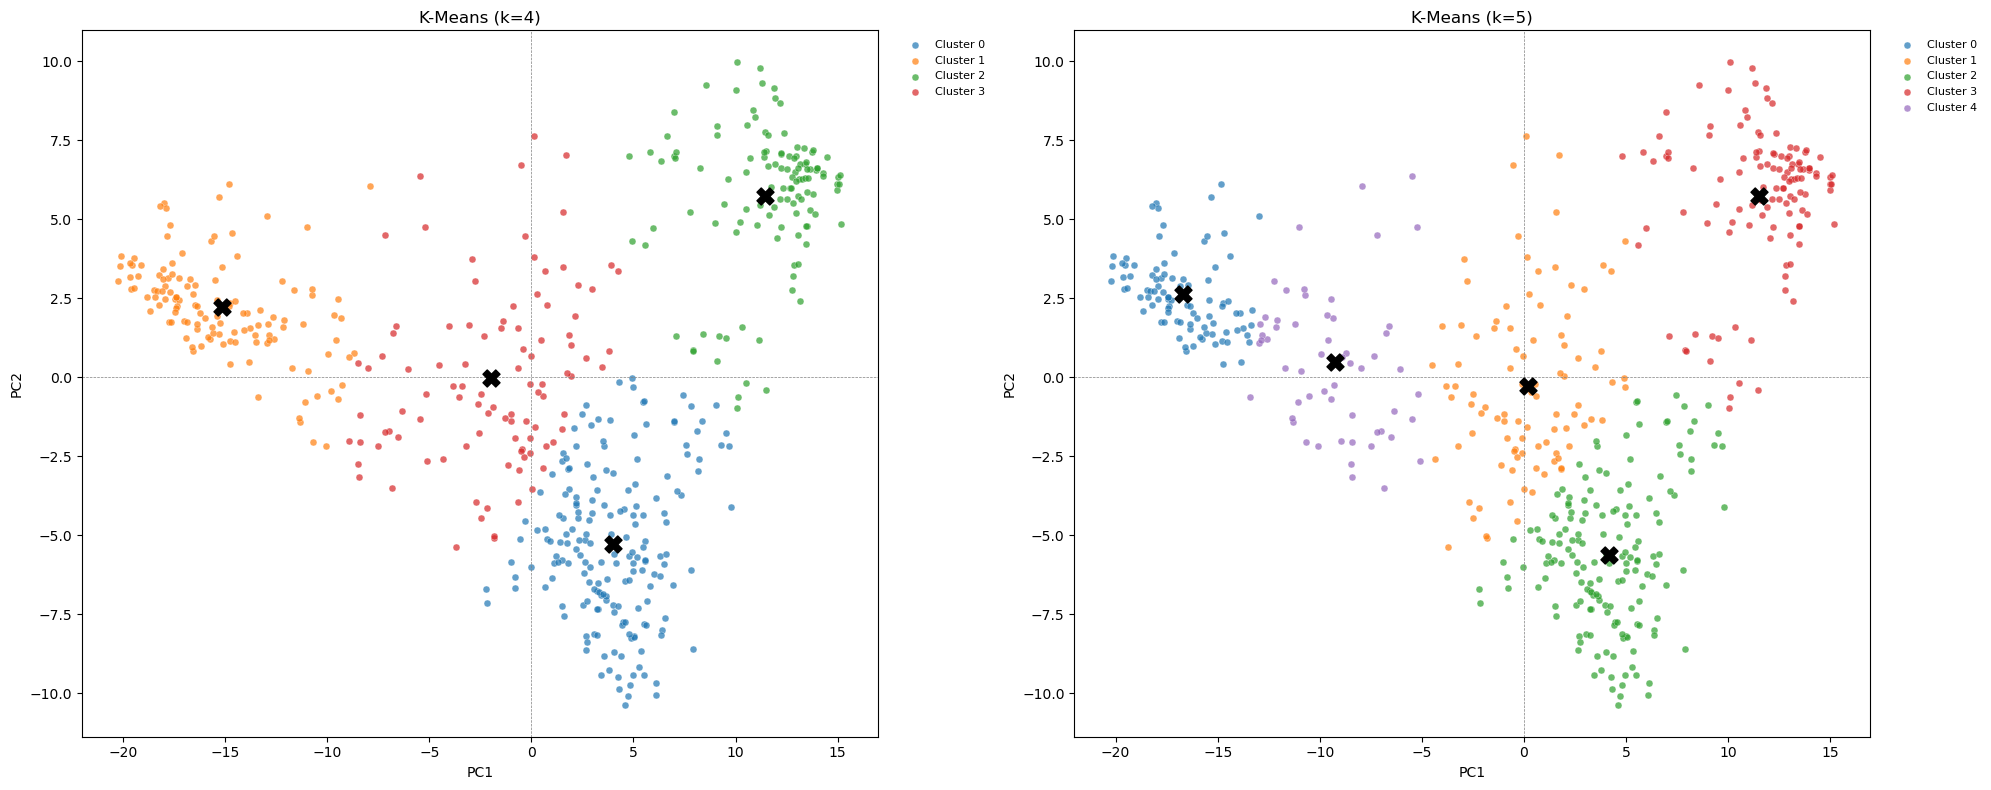

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, k in enumerate([4, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca[['PC1', 'PC2']])
    
    ax = axes[idx]
    for cluster in range(k):
        mask = labels == cluster
        ax.scatter(
            df_pca.loc[mask, 'PC1'],
            df_pca.loc[mask, 'PC2'],
            label=f'Cluster {cluster}',
            alpha=0.7,
            s=25,
            edgecolors='white',
            linewidth=0.3,
        )
    
    centers = km.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=150, zorder=5)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'K-Means (k={k})')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()